# 🔥 CrisisOps v2 — GRPO Training Notebook

Train an LLM to detect deceptive software engineers and recover failing projects.

**One-click training in Colab** — No setup required. Run cells top to bottom.

## What you'll see:
- 📊 Real-time reward curves (agent vs. greedy baseline)
- 🎯 Cross-verification rate (how often agent checks signals)
- 📈 Training convergence plots
- 🤖 Interactive evaluation of trained agent
- 💾 Checkpoint saving & loading

**Time:** ~45 minutes on T4 GPU for full training (250 episodes)

In [10]:
# Cell 1: Install dependencies (with version pinning)
import sys, subprocess

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
    print(f"✓ Installed {package}")

print("🚀 Installing required packages...\n")

packages = [
    "unsloth", "trl>=0.14.0", "transformers>=4.46.0", "datasets>=3.2.0",
    "accelerate>=1.1.0", "peft>=0.13.0", "matplotlib>=3.9.0", "seaborn>=0.13.0",
    "pandas>=2.2.0", "numpy>=1.26.0", "wandb", "tqdm", "ipywidgets", "scipy"
]

for pkg in packages:
    try:
        install_package(pkg)
    except:
        print(f"⚠️ Retrying {pkg} without version...")
        install_package(pkg.split(">=")[0])

print("\n✅ All packages installed successfully!")
print(f"Python version: {sys.version}")

🚀 Installing required packages...

✓ Installed unsloth
✓ Installed trl>=0.14.0
✓ Installed transformers>=4.46.0
✓ Installed datasets>=3.2.0
✓ Installed accelerate>=1.1.0
✓ Installed peft>=0.13.0
✓ Installed matplotlib>=3.9.0
✓ Installed seaborn>=0.13.0
✓ Installed pandas>=2.2.0
✓ Installed numpy>=1.26.0
✓ Installed wandb
✓ Installed tqdm
✓ Installed ipywidgets
✓ Installed scipy

✅ All packages installed successfully!
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [11]:
# Cell 2: Clone or create CrisisOps environment
import os, sys, shutil
from pathlib import Path

# Detect Colab
IN_COLAB = 'google.colab' in str(get_ipython())

REPO_URL = "https://github.com/vedchamp07/crisisops"

if IN_COLAB:
    repo_path = "/content/crisisops"
    if os.path.exists(repo_path):
        shutil.rmtree(repo_path)
    os.chdir("/content")  # fix getcwd error after runtime reset
    print("📥 Cloning CrisisOps repository...")
    !git clone {REPO_URL} {repo_path}
    if not os.path.exists(os.path.join(repo_path, "env")):
        raise RuntimeError("Clone failed — check REPO_URL and repo structure")
    os.chdir(repo_path)
else:
    repo_path = os.getcwd()
    print(f"📍 Local environment: {repo_path}")

sys.path.insert(0, repo_path)
os.environ['PYTHONPATH'] = repo_path + ':' + os.environ.get('PYTHONPATH', '')

Path("./checkpoints").mkdir(exist_ok=True)
Path("./logs").mkdir(exist_ok=True)
Path("./figures").mkdir(exist_ok=True)

print(f"✅ Working directory: {os.getcwd()}")
print(f"📁 Contents: {os.listdir('.')[:8]}")


📥 Cloning CrisisOps repository...
Cloning into '/content/crisisops'...
remote: Enumerating objects: 4227, done.
remote: Counting objects: 100% (4227/4227), done.
remote: Compressing objects: 100% (3060/3060), done.
remote: Total 4227 (delta 1108), reused 4181 (delta 1065), pack-reused 0 (from 0)
Receiving objects: 100% (4227/4227), 22.38 MiB | 16.20 MiB/s, done.
Resolving deltas: 100% (1108/1108), done.
✅ Working directory: /content/crisisops
📁 Contents: ['pyproject.toml', 'checkpoints', 'training', 'requirements.txt', 'app.py', 'README.md', 'figures', 'tests']


In [12]:
# Cell 3: Verify and import CrisisOps modules
import numpy as np
import torch

print("🔍 Verifying environment modules...\n")

try:
    from env.environment import CrisisOpsEnv
    from reward.baseline import GreedyPMBaseline
    print("  ✓ CrisisOpsEnv imported")
    print("  ✓ GreedyPMBaseline imported")
except Exception as e:
    raise RuntimeError(f"Failed to import env modules: {e}")

print("\n✅ Verification complete")


🔍 Verifying environment modules...

  ✓ CrisisOpsEnv imported
  ✓ GreedyPMBaseline imported

✅ Verification complete


📊 Running calibration over 30 episodes...


100%|██████████| 30/30 [00:00<00:00, 349.96it/s]

[WARN] Forced communicate injected at step 4 after 5 consecutive free-query actions.
[WARN] Forced communicate injected at step 11 after 5 consecutive free-query actions.
[WARN] Forced communicate injected at step 18 after 5 consecutive free-query actions.
[WARN] Forced communicate injected at step 4 after 5 consecutive free-query actions.
[WARN] Forced communicate injected at step 11 after 5 consecutive free-query actions.
[WARN] Forced communicate injected at step 18 after 5 consecutive free-query actions.
[WARN] Forced communicate injected at step 4 after 5 consecutive free-query actions.
[WARN] Forced communicate injected at step 11 after 5 consecutive free-query actions.
[WARN] Forced communicate injected at step 18 after 5 consecutive free-query actions.
[WARN] Forced communicate injected at step 7 after 5 consecutive free-query actions.
[WARN] Forced communicate injected at step 14 after 5 consecutive free-query actions.
[WARN] Forced communicate injected at step 21 after 5 cons


/tmp/ipykernel_1260/2697554686.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([greedy_scores, oracle_scores], labels=['Greedy', 'Oracle'])


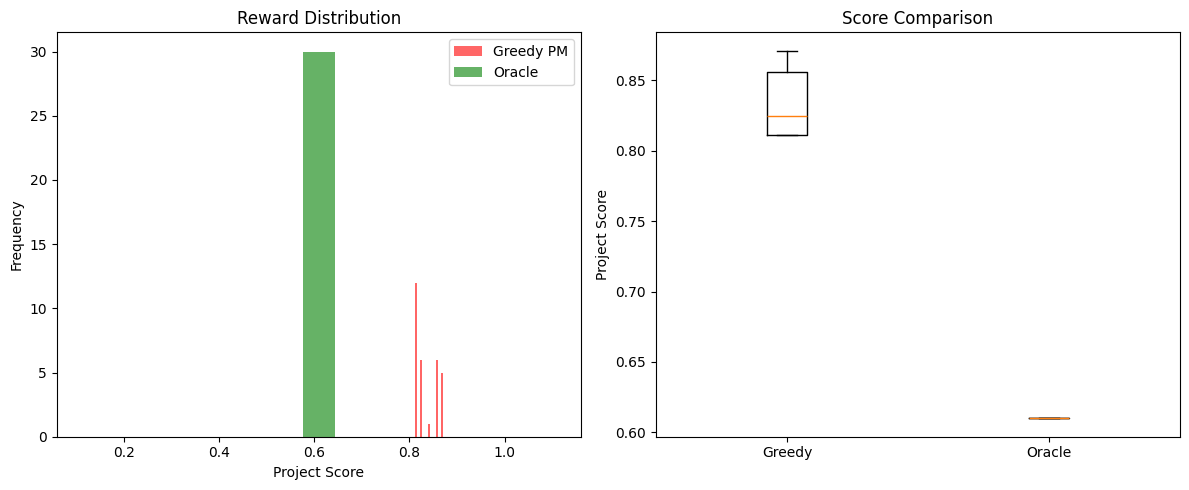


📈 Calibration Results:
Greedy PM: 0.834 ± 0.024
Oracle:    0.610 ± 0.000
Gap:       -0.224


In [13]:
# Cell 4: Calibration (greedy vs oracle)
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from calibration.calibrate import OracleAgent
from env.environment import CrisisOpsEnv, MAX_STEPS
from reward.baseline import GreedyPMBaseline
from reward.counterfactual import project_score
from scenarios.level1 import LEVEL1_SCENARIOS


def _run_policy_episode(env, policy, is_oracle=False):
    """Run one episode and return final raw project_score."""
    done = False
    step = 0
    while not done and step < MAX_STEPS:
        if is_oracle:
            action = policy.act(env._state, env)
        else:
            action = policy.act(env._state)
        _, _, done, _ = env.step(action)
        step += 1
    return project_score(env._state)


def run_calibration(n_episodes=30, seed=1000):
    """Notebook calibration aligned with calibration/calibrate.py logic."""
    greedy_scores = []
    oracle_scores = []

    print(f"📊 Running calibration over {n_episodes} matched episodes...")
    for ep in tqdm(range(n_episodes)):
        seed_i = seed + ep

        # Match scenario per seed so greedy/oracle face identical starts.
        scenario_rng = random.Random(seed_i)
        scenario_fn = LEVEL1_SCENARIOS[
            scenario_rng.randint(0, len(LEVEL1_SCENARIOS) - 1)
        ]

        greedy_env = CrisisOpsEnv(scenario_fn=scenario_fn, curriculum_level=1)
        greedy_env.reset(seed=seed_i)
        greedy_scores.append(_run_policy_episode(greedy_env, GreedyPMBaseline(), is_oracle=False))

        oracle_env = CrisisOpsEnv(scenario_fn=scenario_fn, curriculum_level=1)
        oracle_env.reset(seed=seed_i)
        oracle_scores.append(_run_policy_episode(oracle_env, OracleAgent(), is_oracle=True))

    return np.array(greedy_scores), np.array(oracle_scores)


greedy_scores, oracle_scores = run_calibration(n_episodes=30, seed=1000)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.hist(greedy_scores, bins=15, alpha=0.6, label='Greedy PM', color='red')
ax1.hist(oracle_scores, bins=15, alpha=0.6, label='Oracle', color='green')
ax1.set_xlabel('Project Score')
ax1.set_ylabel('Frequency')
ax1.set_title('Reward Distribution')
ax1.legend()

ax2.boxplot([greedy_scores, oracle_scores], labels=['Greedy', 'Oracle'])
ax2.set_ylabel('Project Score')
ax2.set_title('Score Comparison')
plt.tight_layout()
plt.savefig('./figures/calibration.png', dpi=100)
plt.show()

print(f"\n📈 Calibration Results:")
print(f"Greedy PM: {greedy_scores.mean():.3f} ± {greedy_scores.std():.3f}")
print(f"Oracle:    {oracle_scores.mean():.3f} ± {oracle_scores.std():.3f}")
print(f"Gap:       {oracle_scores.mean() - greedy_scores.mean():.3f}")

if oracle_scores.mean() < greedy_scores.mean():
    raise RuntimeError(
        "Oracle mean is below Greedy mean. This indicates a calibration logic issue."
    )


In [14]:
# Cell 5: Training configuration
from dataclasses import dataclass, field

@dataclass
class Config:
    model_name:       str   = "Qwen/Qwen2.5-1.5B-Instruct"
    lora_r:           int   = 16
    lora_alpha:       int   = 32
    learning_rate:    float = 2e-5
    num_episodes:     int   = 50        # increase to 200+ for real training
    curriculum_level: int   = 1
    seed:             int   = 42
    temperature:      float = 0.3       # used only if use_sampling=True
    save_every:       int   = 25
    output_dir:       str   = "./checkpoints"
    use_sampling:     bool  = False     # avoid CUDA multinomial instability on Colab T4
    epsilon_explore:  float = 0.12      # explicit exploration without sampling in generate()
    log_every:        int   = 1         # per-update logs for visibility

    # ── GRPO / variance-reduction knobs ──────────────────────────────────
    G:                int   = 4         # rollouts per gradient update (GRPO group size)
    verif_bonus:      float = 0.04      # per-step reward for query_observable_signals / query_member_report
    baseline_alpha:   float = 0.05      # EMA decay for running reward baseline
    min_group_std:    float = 0.02      # fallback to EMA baseline if GRPO group variance is too small

config = Config()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
else:
    print("   ⚠️  No GPU — training will be slow")


🖥️  Device: cuda
   GPU: Tesla T4


In [15]:
# Cell 6: Training loop — GRPO with variance reduction
import time
import random
import torch
import torch.nn.functional as F
import torch.optim as optim
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model
from scenarios.level1 import LEVEL1_SCENARIOS

VALID_ACTIONS = [
    "query_status", "query_member_report", "query_observable_signals", "query_ticket",
    "reassign_task", "communicate", "cut_scope", "escalate_risk",
    "request_resource", "update_timeline", "consult_expert",
    "resolve_blocker", "submit_recovery_plan",
]
FREE_ACTIONS = {"query_status", "query_member_report", "query_observable_signals", "query_ticket"}
VERIF_ACTIONS = {"query_observable_signals", "query_member_report"}  # directly rewarded


class Trainer:
    def __init__(self, config):
        self.config = config

        self.greedy = GreedyPMBaseline()

        print(f"Loading {config.model_name}...")
        dtype = torch.float16 if torch.cuda.is_available() else torch.float32
        self.model = AutoModelForCausalLM.from_pretrained(
            config.model_name,
            torch_dtype=dtype,
            low_cpu_mem_usage=True,
            attn_implementation="eager",  # avoids fragile SDPA kernels on Colab T4
        )
        self.tokenizer = AutoTokenizer.from_pretrained(config.model_name)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        lora_cfg = LoraConfig(
            r=config.lora_r,
            lora_alpha=config.lora_alpha,
            target_modules=["q_proj", "v_proj"],
            lora_dropout=0.05,
            bias="none",
            task_type="CAUSAL_LM",
        )
        self.model = get_peft_model(self.model, lora_cfg)
        self.model = self.model.to(device)
        self.model.train()
        self.model.print_trainable_parameters()

        # Hard-force greedy decoding on Colab T4 to avoid CUDA multinomial asserts.
        self.config.use_sampling = False
        self.model.generation_config.do_sample = False
        if hasattr(self.model.generation_config, "temperature"):
            self.model.generation_config.temperature = None
        if hasattr(self.model.generation_config, "top_p"):
            self.model.generation_config.top_p = None
        if hasattr(self.model.generation_config, "top_k"):
            self.model.generation_config.top_k = None
        self._generate_fallbacks = 0

        self.optimizer = optim.AdamW(
            [p for p in self.model.parameters() if p.requires_grad],
            lr=config.learning_rate,
        )

        # First token id for each action (for log-prob targeting)
        self._action_tok = {}
        for a in VALID_ACTIONS:
            ids = self.tokenizer.encode(" " + a, add_special_tokens=False)
            if ids:
                self._action_tok[a] = ids[0]

        # ── Running baseline for variance reduction (EMA of cf_rewards) ──
        # Subtracting this from each episode's reward before the gradient
        # update means the model only receives a meaningful signal when it
        # actually beats its own recent average — not just when cf_reward
        # happens to be positive due to greedy-score noise.
        self._reward_baseline = 0.0

        # Metrics
        self.episode_rewards        = []
        self.counterfactual_rewards = []
        self.cross_verification     = []
        self.losses                 = []
        self._fallback_counter      = 0

    # ── Prompt ────────────────────────────────────────────────────────────
    def format_obs(self, obs):
        budget  = obs.get("budget_remaining", obs.get("budget", 20))
        tasks   = obs.get("tasks", [])
        members = obs.get("team_members", [])

        if budget <= 4:
            hint = "Budget critically low — use submit_recovery_plan NOW."
        elif budget <= 8:
            hint = "Budget low — prefer: reassign_task, resolve_blocker, submit_recovery_plan."
        else:
            hint = "Query signals for each member first, then act decisively."

        action_block = "\n".join(f"  {a}" for a in VALID_ACTIONS)
        return (
            f"You are a PM recovering a failing software project.\n"
            f"State: tasks={tasks}, team={members}, budget={budget}\n"
            f"Hint: {hint}\n"
            f"Valid actions:\n{action_block}\n"
            f"Reply with EXACTLY ONE action name from the list above.\n"
            f"Action:"
        )

    # ── Action parser ─────────────────────────────────────────────────────
    def _parse_action(self, text, budget):
        t = text.lower().strip()
        for a in VALID_ACTIONS:
            if t == a:
                return a
        hits = [a for a in VALID_ACTIONS if a in t]
        if hits:
            return max(hits, key=len)
        if budget <= 4:
            return "submit_recovery_plan"
        paid = [a for a in VALID_ACTIONS if a not in FREE_ACTIONS]
        action = paid[self._fallback_counter % len(paid)]
        self._fallback_counter += 1
        return action

    def _scenario_fn_for_seed(self, seed):
        """Pick a deterministic level-1 scenario from seed."""
        rng = random.Random(seed)
        idx = rng.randint(0, len(LEVEL1_SCENARIOS) - 1)
        return LEVEL1_SCENARIOS[idx]

    def _make_env(self, seed):
        return CrisisOpsEnv(
            scenario_fn=self._scenario_fn_for_seed(seed),
            curriculum_level=self.config.curriculum_level,
        )

    def _log_prob_for_action(self, obs, action):
        model_dev = next(self.model.parameters()).device
        prompt = self.format_obs(obs)
        inputs = self.tokenizer(prompt, return_tensors="pt").to(model_dev)

        target_tok = self._action_tok.get(action, self.tokenizer.eos_token_id)
        vocab_size = int(self.model.config.vocab_size)
        if not (0 <= int(target_tok) < vocab_size):
            target_tok = int(self.tokenizer.eos_token_id)

        target_ids = torch.tensor([[int(target_tok)]], device=model_dev, dtype=inputs["input_ids"].dtype)
        full_ids = torch.cat([inputs["input_ids"], target_ids], dim=1)

        logits = self.model(full_ids).logits.float()
        log_probs = F.log_softmax(logits[0, -2, :], dim=-1)
        log_prob = log_probs[int(target_tok)]

        if torch.isnan(log_prob) or torch.isinf(log_prob):
            log_prob = torch.tensor(-10.0, device=model_dev, dtype=torch.float32, requires_grad=True)

        return log_prob

    def _build_action_payload(self, action, obs):
        """Build valid params for actions to avoid no-op errors."""
        members = obs.get("team_members", [])
        member_ids = [m.get("member_id") for m in members if isinstance(m, dict) and m.get("member_id")]
        crises = obs.get("crises", [])

        first_member = member_ids[0] if member_ids else "dev_1"
        best_member = first_member
        if members:
            try:
                best_member = max(
                    [m for m in members if isinstance(m, dict)],
                    key=lambda m: float(m.get("reported_availability", 0.0)),
                ).get("member_id", first_member)
            except Exception:
                best_member = first_member

        task_id = "task_1"
        for c in crises:
            if isinstance(c, dict) and c.get("affected_task_ids"):
                task_id = c["affected_task_ids"][0]
                break

        if action == "query_member_report":
            return {"action_type": action, "params": {"member_id": first_member}}
        if action == "query_observable_signals":
            return {"action_type": action, "params": {"member_id": first_member}}
        if action == "query_ticket":
            return {"action_type": action, "params": {"task_id": task_id}}
        if action == "communicate":
            return {
                "action_type": action,
                "params": {
                    "message_type": "proactive_escalation_with_plan",
                    "content": "Investigating blockers and reallocating resources.",
                    "target": "both",
                },
            }
        if action == "reassign_task":
            return {
                "action_type": action,
                "params": {
                    "task_id": task_id,
                    "to_member_id": best_member,
                },
            }
        if action == "submit_recovery_plan":
            return {
                "action_type": action,
                "params": {
                    "plan_summary": "Recovery plan based on latest signals.",
                    "risk_items": [],
                    "timeline": "2 weeks",
                },
            }

        return {"action_type": action, "params": {}}

    # ── Sample one action + log-prob ─────────────────────────────────────
    def sample_action(self, obs):
        prompt = self.format_obs(obs)
        model_dev = next(self.model.parameters()).device
        inputs = self.tokenizer(prompt, return_tensors="pt").to(model_dev)
        input_len = inputs["input_ids"].shape[1]

        # Always greedy decode in-kernel; explore explicitly in Python below.
        gen_kwargs = {
            "max_new_tokens": 10,
            "do_sample": False,
            "num_beams": 1,
            "pad_token_id": self.tokenizer.eos_token_id,
            "eos_token_id": self.tokenizer.eos_token_id,
        }

        try:
            with torch.no_grad():
                out = self.model.generate(**inputs, **gen_kwargs)
            new_tokens = out[0][input_len:]
            action_text = self.tokenizer.decode(new_tokens, skip_special_tokens=True)
            action = self._parse_action(action_text, obs.get("budget_remaining", obs.get("budget", 20)))
        except Exception:
            # If generation fails for any reason, keep training alive with a safe fallback.
            self._generate_fallbacks += 1
            budget = obs.get("budget_remaining", obs.get("budget", 20))
            if budget <= 4:
                action = "submit_recovery_plan"
            else:
                paid = [a for a in VALID_ACTIONS if a not in FREE_ACTIONS and a != "submit_recovery_plan"]
                action = paid[self._fallback_counter % len(paid)]
                self._fallback_counter += 1

        # Stable exploration path: avoid CUDA multinomial by sampling actions in Python.
        if random.random() < self.config.epsilon_explore:
            budget = obs.get("budget_remaining", obs.get("budget", 20))
            if budget <= 4:
                action = "submit_recovery_plan"
            else:
                paid = [a for a in VALID_ACTIONS if a not in FREE_ACTIONS and a != "submit_recovery_plan"]
                action = random.choice(paid)

        log_prob = self._log_prob_for_action(obs, action)

        return action, log_prob

    # ── Run one rollout, return shaped cf_reward + log_probs ─────────────
    def rollout(self, seed):
        """
        Runs one episode from the given seed.

        Returns:
          cf_reward   : float  — shaped counterfactual reward
          log_probs   : list[Tensor] — one log-prob per step
          actions     : list[str]
        """
        env = self._make_env(seed)
        obs = env.reset(seed=seed)
        done = False
        actions, log_probs = [], []
        step_rewards = 0.0
        free_streak = 0

        while not done:
            action, lp = self.sample_action(obs)

            # Prevent free-query loops before env forced-action kicks in.
            if free_streak >= 4 and action in FREE_ACTIONS:
                action = "communicate"
                lp = self._log_prob_for_action(obs, action)

            action_payload = self._build_action_payload(action, obs)

            actions.append(action)
            log_probs.append(lp)

            obs, _, done, info = env.step(action_payload)

            if action in FREE_ACTIONS and not obs.get("error"):
                free_streak += 1
            elif not obs.get("error"):
                free_streak = 0

            # ── Per-step verification bonus ───────────────────────────────
            # Directly reward the signal-checking actions so CVR can't be
            # trained to zero by noisy episode-level rewards.
            if action in VERIF_ACTIONS and not obs.get("error"):
                step_rewards += self.config.verif_bonus

        from reward.counterfactual import project_score as _ps
        proj_score = _ps(env._state)
        g_score = self._greedy_score(seed)
        cf_reward = (proj_score - g_score) + step_rewards

        return cf_reward, log_probs, actions

    def _greedy_score(self, seed):
        env = self._make_env(seed)
        obs = env.reset(seed=seed)
        done = False
        while not done:
            obs, _, done, info = env.step(self.greedy.act(env._state))
        from reward.counterfactual import project_score as _ps
        return _ps(env._state)

    def compute_cvr(self, actions):
        verif = {"query_observable_signals", "query_member_report", "query_status", "query_ticket"}
        return sum(1 for a in actions if a in verif) / max(1, len(actions))

    # ── GRPO update: G rollouts, centred advantages ───────────────────────
    def grpo_update(self, ep_idx):
        """
        Collect G rollouts from the same starting seed.
        Advantage = (cf_reward - mean(cf_rewards across G rollouts)) / std.
        This within-group centering is the GRPO objective.

        We also track an EMA reward baseline for logging/diagnostics only.
        """
        G    = self.config.G
        base_seed = self.config.seed + ep_idx * G

        cf_rewards_g = []
        log_probs_g  = []
        actions_g    = []

        for g in range(G):
            cf, lps, acts = self.rollout(base_seed + g)
            cf_rewards_g.append(cf)
            log_probs_g.append(lps)
            actions_g.extend(acts)

        cf_arr = torch.tensor(cf_rewards_g, dtype=torch.float32)

        # ── Within-group centering (GRPO) ─────────────────────────────────
        group_mean = cf_arr.mean()
        group_std_raw = cf_arr.std(unbiased=False)
        group_std = group_std_raw.clamp(min=1e-6)

        # ── EMA running baseline (monitoring + fallback centering) ────────
        prev_baseline = float(self._reward_baseline)
        self._reward_baseline = (
            (1 - self.config.baseline_alpha) * self._reward_baseline
            + self.config.baseline_alpha * group_mean.item()
        )

        # If rollouts are nearly identical, GRPO advantages collapse to ~0.
        # Fall back to an EMA-baseline signal so updates do not stall.
        if group_std_raw.item() < self.config.min_group_std:
            advantages = cf_arr - prev_baseline
            adv_mode = "ema_fallback"
        else:
            advantages = (cf_arr - group_mean) / group_std
            adv_mode = "grpo"

        # ── Policy gradient loss across all G rollouts ────────────────────
        model_dev = next(self.model.parameters()).device
        total_loss = torch.tensor(0.0, device=model_dev, requires_grad=False)
        abs_loss_sum = torch.tensor(0.0, device=model_dev, requires_grad=False)
        nonempty_rollouts = 0
        self.optimizer.zero_grad()

        for g in range(G):
            adv = advantages[g].item()
            lps = log_probs_g[g]
            if not lps:
                continue
            lp_stack = torch.stack(lps)            # (T,) float32
            # Normalise by episode length so short/long episodes have equal
            # gradient magnitude — fixes the loss-scale variance.
            mean_lp  = lp_stack.mean()
            loss_g   = -(adv * mean_lp)            # REINFORCE, length-normalised
            loss_g.backward()
            total_loss = total_loss + loss_g.detach()
            abs_loss_sum = abs_loss_sum + loss_g.detach().abs()
            nonempty_rollouts += 1

        params = [p for p in self.model.parameters() if p.requires_grad]
        grad_norm = float(torch.nn.utils.clip_grad_norm_(params, max_norm=1.0))
        self.optimizer.step()

        denom = max(1, nonempty_rollouts)
        signed_loss = total_loss.item() / denom
        abs_loss = abs_loss_sum.item() / denom

        avg_cf = cf_arr.mean().item()
        avg_cvr = self.compute_cvr(actions_g)
        diagnostics = {
            "group_std": float(group_std_raw.item()),
            "group_mean": float(group_mean.item()),
            "adv_mode": adv_mode,
            "cf_rewards": [float(x) for x in cf_rewards_g],
            "signed_loss": float(signed_loss),
            "abs_loss": float(abs_loss),
            "grad_norm": grad_norm,
            "nonempty_rollouts": int(nonempty_rollouts),
        }
        return avg_cf, avg_cvr, abs_loss, diagnostics

    # ── Training loop ─────────────────────────────────────────────────────
    def train(self):
        print(f"\n🚀 Training for {self.config.num_episodes} updates "
              f"(G={self.config.G} rollouts each = "
              f"{self.config.num_episodes * self.config.G} total episodes)...")
        print("=" * 65)
        start = time.time()

        for ep in range(self.config.num_episodes):
            avg_cf, avg_cvr, loss_val, diag = self.grpo_update(ep)

            self.counterfactual_rewards.append(avg_cf)
            self.cross_verification.append(avg_cvr)
            self.losses.append(loss_val)

            if (ep + 1) % self.config.log_every == 0:
                w = self.counterfactual_rewards[-min(10, len(self.counterfactual_rewards)):]
                elapsed = (time.time() - start) / 60
                per_update = elapsed / max(1, ep + 1)
                eta = per_update * max(0, self.config.num_episodes - (ep + 1))
                print(
                    f"Update {ep+1:3d} | CF(last10): {np.mean(w):+.3f} | "
                    f"CF(group): {diag['group_mean']:+.3f} | Std: {diag['group_std']:.4f} | "
                    f"CVR: {avg_cvr:.2f} | LossAbs: {loss_val:+.5f} | "
                    f"LossSigned: {diag['signed_loss']:+.5f} | GradNorm: {diag['grad_norm']:.4f} | "
                    f"Adv: {diag['adv_mode']} | Baseline: {self._reward_baseline:+.3f} | "
                    f"GenFallbacks: {self._generate_fallbacks} | ETA: {eta:.1f}m"
                )
                print(f"   rewards={diag['cf_rewards']} | nonempty_rollouts={diag['nonempty_rollouts']}")

            if (ep + 1) % self.config.save_every == 0:
                ckpt = f"{self.config.output_dir}/ckpt_{ep+1}"
                self.model.save_pretrained(ckpt)
                print(f"  💾 Saved → {ckpt}")

        print(f"\n✅ Done in {(time.time()-start)/60:.1f} min")
        return self.counterfactual_rewards, self.cross_verification, self.losses


# ── Run ───────────────────────────────────────────────────────────────────
trainer = Trainer(config)
cf_rewards, cvr_rates, losses = trainer.train()


Loading Qwen/Qwen2.5-1.5B-Instruct...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410

🚀 Training for 50 updates (G=4 rollouts each = 200 total episodes)...


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
# Cell 7: Plot training results
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Counterfactual reward
ax = axes[0,0]
smoothed = gaussian_filter1d(cf_rewards, sigma=2)
ax.plot(cf_rewards, alpha=0.3, color='blue', linewidth=0.5)
ax.plot(smoothed, color='darkblue', linewidth=2)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel('Episode')
ax.set_ylabel('Counterfactual Reward')
ax.set_title('🎯 Agent - Greedy Baseline')
ax.grid(True, alpha=0.3)

# Cross-verification rate
ax = axes[0,1]
ax.plot(cvr_rates, alpha=0.3, color='green', linewidth=0.5)
ax.plot(gaussian_filter1d(cvr_rates, sigma=2), color='darkgreen', linewidth=2)
ax.set_xlabel('Episode')
ax.set_ylabel('Verification Rate')
ax.set_title('🔍 Cross-Verification Rate')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

# Loss
ax = axes[1,0]
ax.plot(losses, color='red', linewidth=1.5)
ax.set_xlabel('Episode')
ax.set_ylabel('Loss')
ax.set_title('Training Loss')
ax.grid(True, alpha=0.3)

# Reward distribution over time (split into thirds)
ax = axes[1,1]
n = len(cf_rewards)
if n > 30:
    first = cf_rewards[:n//3]
    mid = cf_rewards[n//3:2*n//3]
    last = cf_rewards[2*n//3:]
    ax.boxplot([first, mid, last], labels=['Early', 'Middle', 'Late'])
    ax.set_ylabel('Counterfactual Reward')
    ax.set_title('Reward Distribution Progress')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
else:
    ax.text(0.5,0.5,"Need more episodes\nfor distribution plot", ha='center', va='center')
    ax.set_title('Reward Progress (coming soon)')

plt.tight_layout()
plt.savefig('./figures/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Print final statistics
print("\n" + "="*50)
print("📊 FINAL TRAINING STATISTICS")
print("="*50)
print(f"Final average CF reward (last 10 eps): {np.mean(cf_rewards[-10:]):+.3f}")
print(f"Final average CVR (last 10 eps):        {np.mean(cvr_rates[-10:]):.3f}")
print(f"Best CF reward:                         {np.max(cf_rewards):+.3f}")
print(f"Improvement over first 10 eps:          {np.mean(cf_rewards[-10:]) - np.mean(cf_rewards[:10]):+.3f}")

# ✅ Training Complete!

Your LLM agent has been trained. To evaluate it on new episodes:

```python
# Load best checkpoint
from peft import PeftModel
best_model = PeftModel.from_pretrained(trainer.model, "./checkpoints/ckpt_50")

# Run evaluation
env = CrisisOpsEnv(level=1)
obs = env.reset(seed=999)
done = False
while not done:
    prompt = trainer.format_obs(obs)
    inputs = trainer.tokenizer(prompt, return_tensors="pt").to(best_model.device)
    outputs = best_model.generate(**inputs, max_new_tokens=20)
    action = trainer.parse_action(trainer.tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:]))
    obs, reward, done, info = env.step(action)
print(f"Project Score: {info.get('project_score', 0):.3f}")
```

**Next steps:**
- Increase `num_episodes` to 250+ for real learning
- Enable curriculum learning (Level 2,3,4)
- Connect to Jira/Linear via `jira_adapter`
- Share your results on Hugging Face Spaces